In [ ]:
### Notes: Needs correct conda environment. 

In [15]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.model_selection import train_test_split
import re
import random
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import joblib
from scipy.stats import lognorm

In [123]:
def log_prob(x):
    """
    Calculate the log probability of a given set of parameters.

    Parameters:
    x (array): The input parameters.

    Returns:
    float: The log probability of the input parameters.
    """
    # Inverse transform the input parameters
    x = scaler_pars.inverse_transform(x.reshape(1, -1))
    print(x)
    x = pd.DataFrame({
        'p_taper': x[0][0],
        'ball_berry_slope': x[0][1],
        'Vcmax25': x[0][2],
        'sla_top': x[0][3],
        'p50_node_aroot': x[0][4],
        'rs2': x[0][5]
    }, index=[0])
    # Initialize the output
    #print(x)
    DFout=0
    #DFout=pd.DataFrame({})
    # loop through all our model types
    for i in list(range(0,len(Model_List))):
        #print(i)
        # load new model/scaler
        regr = regrli[Model_List[i]]
        scaler = scarlerli[Scaler_List[i]]
        Weight = Weight_list[i]
        ob_set=Obs_save[Obs_save["Set"]==Obs_List[i]]
        if (Obs_List[i] =="LWPmin")|(Obs_List[i] =="LWPmax"):
            my = ob_set[["year", "DOY"]].reset_index(drop=True)
            my["Year"] = my["year"]
            my = my[["Year", "DOY"]]
            ob_set = ob_set.sort_values(["year", "DOY"])
            x_1_run_set = pd.concat([pd.concat([x] * len(my)).reset_index(), my], axis=1)
            one = x_1_run_set.iloc[:, 1:].sort_values(["Year", "DOY"])
            one = one.set_axis(Names2, axis=1)
        else: 
           
            my = ob_set[["year", "month"]].reset_index(drop=True)
            ob_set = ob_set.sort_values(["year", "month"])
            x_1_run_set = pd.concat([pd.concat([x] * len(my)).reset_index(), my], axis=1)
            one = x_1_run_set.iloc[:, 1:].sort_values(["year", "month"])
            one = one.set_axis(Names, axis=1)

        one= scaler.transform(one)
        predicty=regr.predict(one)
        Frame=pd.concat([ob_set.reset_index(drop=True),pd.Series(predicty,name="sim").reset_index(drop=True)],axis=1)
        Frame.loc[Frame['sim']<.00001,0]=0.0001
        if (Obs_List[i] =="LWPmin")|(Obs_List[i] =="LWPmax"):
            Frame["obs"]=abs(Frame["obs"])
            Frame["sim"]=abs(Frame["sim"])
        #DFout=pd.concat([DFout,Frame])
        #print(len(DFout))
        ll1 = -np.sum(lognorm.pdf(Frame['sim'], s=Frame['error'], scale=np.exp(Frame["obs"])))

        # Update the outputg
        DFout += ll1 * Weight

        # Check physical possibility
        p =sum([1 for t in range(len(x.columns)) if (x.iloc[0, t] < samples[[x.columns[t]]].min().values) or (x.iloc[0, t] > samples[[x.columns[t]]].max().values)])
        if p >=1:
            DFout= -np.inf
    DFout=(DFout)
#    print(DFout)
    return (DFout)
   
def acceptance(x_likelihood, x_new_likelihood):
    if x_new_likelihood>x_likelihood:
        return True
    else:
        accept=np.random.uniform(0,1)
        # Since we did a log likelihood, we need to exponentiate in order to compare to the random number
        # less likely x_new are less likely to be accepted
        print(x_likelihood/x_new_likelihood)
        return (accept < x_likelihood/x_new_likelihood)
        #return(np.exp(x_likelihood-x_new_likelihood))


In [8]:
samples=pd.read_csv('C:/Users/345578/Desktop/ML_scaler/LHS.sam.csv')
Varset= ['p_taper',
       'ball_berry_slope', 'Vcmax25', 'sla_top', 'p50_node_aroot','rs2']
samples_sub=samples[Varset]
scaler_pars =StandardScaler().fit(samples_sub.values)
Names=pd.concat([pd.Series(samples_sub.columns),pd.Series(["year","month",])])
Names2=pd.concat([pd.Series(samples_sub.columns),pd.Series(["Year","DOY",])])

In [36]:
Names

0             p_taper
1    ball_berry_slope
2             Vcmax25
3             sla_top
4      p50_node_aroot
5                 rs2
0                year
1               month
dtype: object

In [17]:
Emdir = "C:/Users/345578/Desktop/NewML/ML_models/"
Obsdir="C:/Users/383517/Desktop/LT2024/Machine_Learning/FATES_emulator/"
Datadir="C:/Users/383517/Desktop/LT2024/Machine_Learning/Data/"
Weight_list=[10.0,10.0,10,10.0,0.2,.2,10]
#Model_List = ["GPP_minvar_", "H2oSOI1_minvar", "H2oSOI7_minvar", "H2oSOI7_minvar"]
Model_List = ["ET_full_012825", "GPP_minvar_012825",'H2oSOI1_minvar_012825',"LWP_max_model_012825",
             "LWP_min_model_012825","RO_minvar_031125"]

Scaler_List = ["ET_full_012825_Scalar","GPP_minvar_031125_Scalar","H2oSOI1_minvar_012825_Scalar",
              "LWP_max_model_012825_Scalar","LWP_min_model_012825_Scalar","RO_minvar_031125_Scalar"]
Obs_List = ["ET",'MonthlyGPP', 'SWC10',"LWPmax","LWPmin",'Runoff']


In [4]:
LOADIN=True





if LOADIN== True: 
    regrli={}
    scarlerli={}
    for i in list(range(0,len(Model_List))) :
        print(i)
    
     # load new model/scaler
        variable_name=Model_List[i]
        regrli[Model_List[i]]=joblib.load(Emdir+Model_List[i]+'.joblib')
        print(regrli)
        scarlerli[Scaler_List[i]]=joblib.load(Emdir+Scaler_List[i]+'.joblib')
        

0
{'ET_full_012825': RandomForestRegressor()}
1
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor()}
2
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor()}
3
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor(), 'LWP_max_model_012825': RandomForestRegressor()}
4
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor(), 'LWP_max_model_012825': RandomForestRegressor(), 'LWP_min_model_012825': RandomForestRegressor()}
5
{'ET_full_012825': RandomForestRegressor(), 'GPP_minvar_012825': RandomForestRegressor(), 'H2oSOI1_minvar_012825': RandomForestRegressor(), 'LWP_max_model_012825': RandomForestRegressor(), 'LWP_min_model_012825': RandomForestRegressor(), 'RO_minvar_031125': RandomForestRegressor()}


In [157]:
list1=['MonthlyGPP', 'Runoff', 'SWC10', 'SWC40', 'SWC100', 'ET', 'LWPmin',
       'LWPmax']
Obs_save=pd.read_csv("C:/Users/345578/Desktop/NewML/Synth/Syntheticg_Set3_63025.csv").iloc[:,1:]
Obs_save=Obs_save.dropna()
Obs_save['Date']=pd.to_datetime(Obs_save["Date"])
Obs_save["year"]=Obs_save["Date"].dt.year
Obs_save["month"]=Obs_save["Date"].dt.month
Obs_save["DOY"]=Obs_save["Date"].dt.dayofyear

Obs_save.loc[Obs_save["Set"]==list1[0],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[0],'obs'].mean()*0.1)
Obs_save.loc[Obs_save["Set"]==list1[1],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[1],'obs'].mean()*.01)
Obs_save.loc[Obs_save["Set"]==list1[2],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[2],'obs'].mean()*.1)
Obs_save.loc[Obs_save["Set"]==list1[3],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[3],'obs'].mean()*.1)
Obs_save.loc[Obs_save["Set"]==list1[4],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[4],'obs'].mean()*.1)
Obs_save.loc[Obs_save["Set"]==list1[5],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[5],'obs'].mean()*.1)
Obs_save.loc[Obs_save["Set"]==list1[6],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[6],'obs'].mean()*.1)
Obs_save.loc[Obs_save["Set"]==list1[7],'error']=abs(Obs_save.loc[Obs_save["Set"]==list1[7],'obs'].mean()*.1)


initialpos=110
#initial_position=#[samples_sub.iloc[[initialpos]].T,samples_sub]
initial_position=np.array(samples_sub.iloc[[initialpos]].T)
print(initial_position)
Logl=log_prob(x_1)

Logl


[[3.08589257e-01]
 [8.04984534e+00]
 [1.12994348e+02]
 [9.08607297e-03]
 [3.25707002e+00]
 [1.35858614e-01]]


AttributeError: 'list' object has no attribute 'reshape'

In [182]:
V=pd.read_csv('C:/Users/345578/Desktop/ML_scaler/SDinmcm_v2_0_minparam.csv')
print(V)
#R=np.corrcoef(samples_sub[:1000].transpose())

#V2=V['SD'].values*1###(between 50 and 100 times more) ## matbe 30-50
S=[1,1,1,1,1,1]
C=np.outer(S,S)
C


                                      b        SD    example
0           fates_mort_hf_flc_threshold  0.080000   0.816671
1                fates_hydro_resid_node  0.040000   0.433967
2                   fates_hydro_p_taper  0.200000   0.448444
3   fates_leaf_stomatal_slope_ballberry  0.750000   7.549666
4                 fates_leaf_vcmax25top  5.000000  53.809144
5                     fates_leaf_slatop  0.001600   0.008204
6               fates_hydro_kmax_rsurf2  0.000351   0.000351
7                  fates_hydro_p50_node  1.200000   0.843964
8                fates_hydro_pitlp_node  0.240000   1.292132
9                       fates_hydro_rs2  0.400000   0.175299
10               fates_hydro_epsil_node  4.200000  21.480004


array([[1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1]])

In [181]:
x_1=samples_sub.iloc[[15]].T
print(x_1)

                         15
p_taper            0.204581
ball_berry_slope   9.539231
Vcmax25           31.588925
sla_top            0.013868
p50_node_aroot     0.227198
rs2                0.098753


In [185]:

varlist=samples
#par_cov_matrix=np.cov(samples[:1000].transpose())
par_cov_matrix=C
Ac_count=0
newlog=pd.DataFrame([])
acceptlog=pd.DataFrame([])
scorelog=np.array([])
namelog=np.array([])




x_1=samples_sub.iloc[[559]].T
print(x_1)
x_1=scaler_pars.transform(np.array(x_1).flatten().reshape(1, -1)).flatten()
Logl=log_prob(x_1)
#Logl=LL(Outputs)
#print(Logl)
for time in list(range(1,10000)):
    print(time)
    newproposed=np.random.multivariate_normal(np.array(x_1),par_cov_matrix, size=1).tolist()[0]
    #print(newproposed)
    
    NewLogl=log_prob(np.array(newproposed))

#    print(Logl)
#    print(NewLogl)
    newlog=pd.concat([newlog,pd.DataFrame(newproposed)],axis=1)
    scorelog=np.append(scorelog,Logl)
    if (acceptance(Logl,NewLogl)):
        Logl=NewLogl
        print(Logl)
        acceptlog=pd.concat([acceptlog,pd.DataFrame(newproposed)],axis=1)
        x_1=newproposed
        print('Accept')
        Ac_count=Ac_count+1
        #print(Ac_count)

                        559
p_taper            0.396514
ball_berry_slope  14.115947
Vcmax25           76.863361
sla_top            0.041146
p50_node_aroot     1.667895
rs2                0.022788
[[3.96514078e-01 1.41159466e+01 7.68633612e+01 4.11463962e-02
  1.66789529e+00 2.27875648e-02]]
1
[[ 3.61416520e-01  1.31131118e+01  6.93424380e+01  3.75530873e-02
   1.17794594e+00 -3.05805940e-02]]
0.0
2
[[7.99158890e-01 2.56206281e+01 1.63144598e+02 8.23694115e-02
  7.28867282e+00 6.35035637e-01]]
0.0
3
[[ 3.31540076e-01  1.22594587e+01  6.29403273e+01  3.44943191e-02
   7.60881450e-01 -7.60097054e-02]]
0.0
4
[[ 1.73231176e-01  7.73613355e+00  2.90169121e+01  1.82865604e-02
  -1.44905407e+00 -3.16728851e-01]]
0.0
5
[[5.60836437e-01 1.88110931e+01 1.12075379e+02 5.79698167e-02
  3.96177660e+00 2.72650578e-01]]
0.0
6
[[5.24459719e-01 1.77717091e+01 1.04280349e+02 5.42455467e-02
  3.45397062e+00 2.17337371e-01]]
0.0
7
[[5.25038524e-01 1.77882471e+01 1.04404379e+02 5.43048050e-02
  3.46205052e+

In [186]:
Ac_count

1536

In [187]:
scorelog.min()

-0.30216203667283326

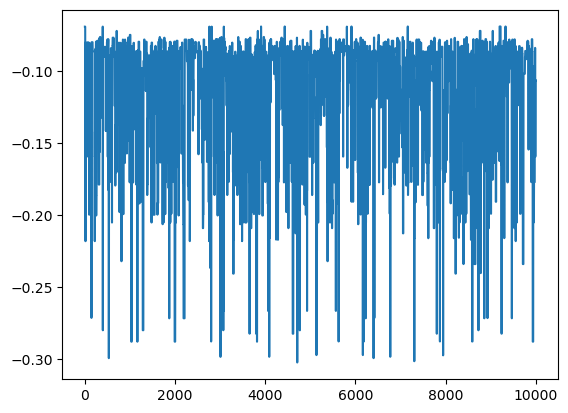

In [188]:
plt.plot(scorelog) 

In [114]:
Out1

NameError: name 'Out1' is not defined

In [105]:
x_1=[bounce(samples_sub.iloc[[0]].T,samples_sub).T]
Outputs=ML_outputs(x_1)

Out1=Outputs.loc[Outputs['Set']==Outputs['Set'].unique()[0]]
len(Outputs)

TypeError: boundby() missing 1 required positional argument: 'name'

In [132]:
newlog.T

,0,1,2,3,4,5
0,0.608727,-1.026439,1.294822,0.741533,-1.101937,-0.663191
0,0.534821,-1.100345,1.220916,0.667627,-1.175843,-0.737098
0,-0.772402,-2.407568,-0.086307,-0.639596,-2.483066,-2.044320
0,1.160188,-0.474978,1.846283,1.292994,-0.550476,-0.111730
0,-0.574736,-2.209902,0.111359,-0.441930,-2.285400,-1.846655
...,...,...,...,...,...,...
0,0.228493,-1.406673,0.914588,0.361299,-1.482171,-1.043426
0,0.267059,-1.368107,0.953154,0.399865,-1.443605,-1.004859
0,0.576034,-1.059131,1.262130,0.708841,-1.134629,-0.695884
0,1.247402,-0.387763,1.933498,1.380209,-0.463261,-0.024516


In [166]:
newlog2=scaler_pars.inverse_transform(newlog.T)

In [191]:
pd.DataFrame(newlog2).to_csv("C:/Users/345578/Desktop/NewML/MCMC_runs/TestMC75_3.csv")


In [2]:
for i in list(range(0,11)):
    times=2
    print(V["b"][i])
    print(V["SD"][i]*times)
    plt.acorr(newlog2[:100,i],maxlags=98) 
    plt.show()
    plt.plot(newlog2[:,i])
    plt.show()

NameError: name 'V' is not defined

In [215]:
V["b"]

0             fates_mort_hf_flc_threshold
1                  fates_hydro_resid_node
2                     fates_hydro_p_taper
3     fates_leaf_stomatal_slope_ballberry
4                   fates_leaf_vcmax25top
5                       fates_leaf_slatop
6                 fates_hydro_kmax_rsurf2
7                    fates_hydro_p50_node
8                  fates_hydro_pitlp_node
9                         fates_hydro_rs2
10                 fates_hydro_epsil_node
Name: b, dtype: object

fates_mort_hf_flc_threshold
0.16


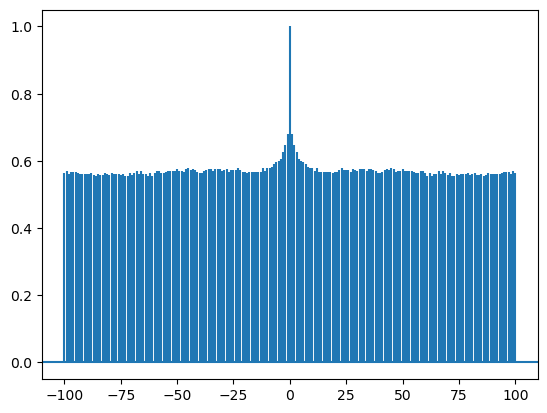

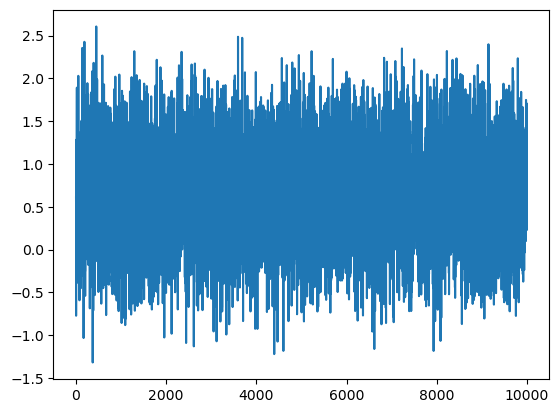

fates_hydro_resid_node
0.08


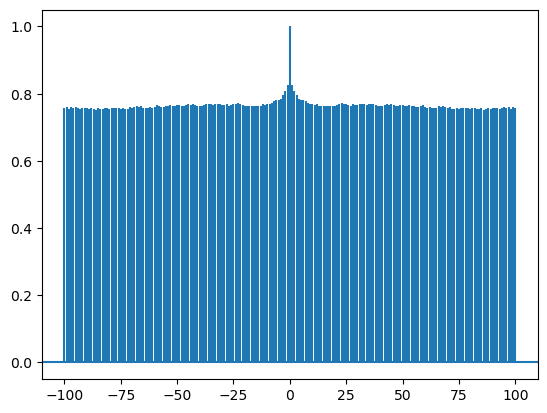

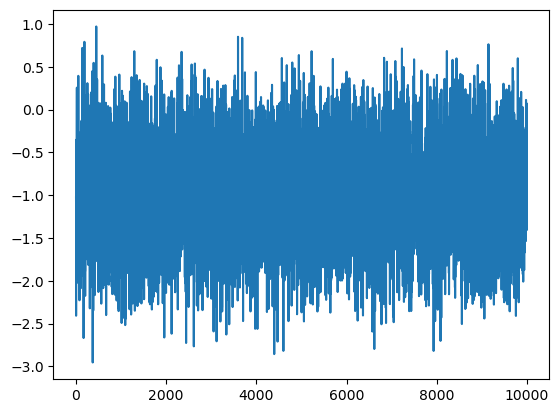

fates_hydro_p_taper
0.4


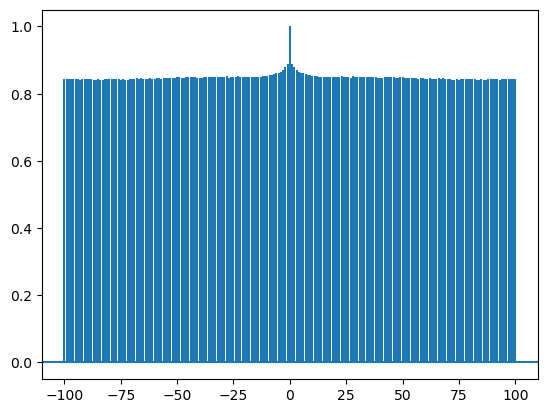

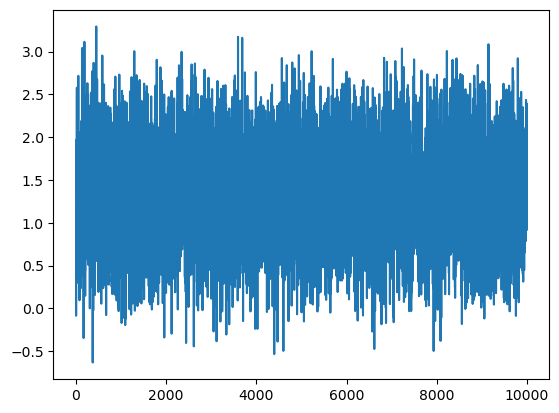

fates_leaf_stomatal_slope_ballberry
1.5


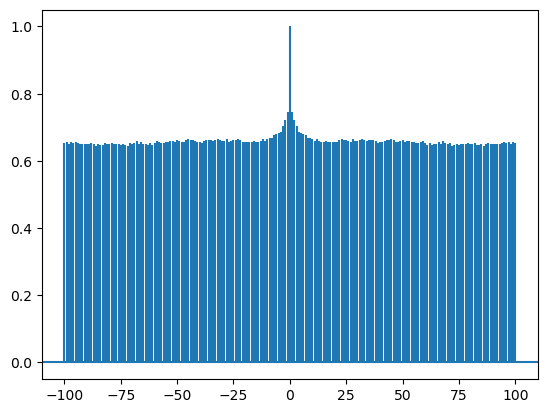

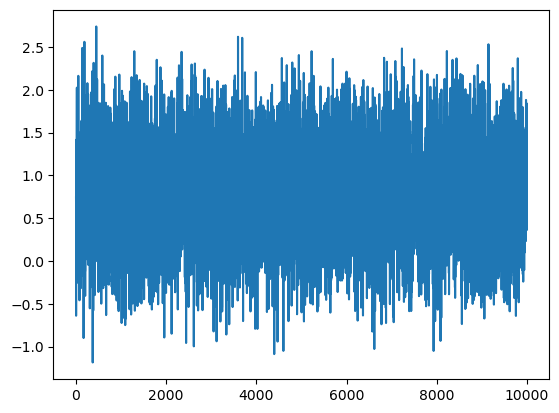

fates_leaf_vcmax25top
10.0


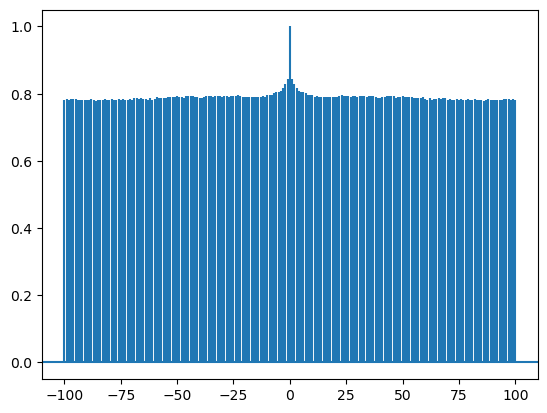

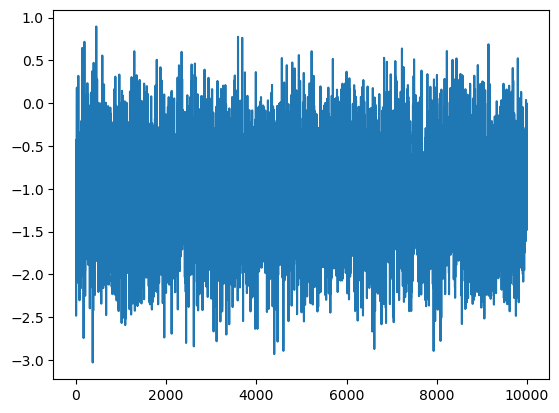

fates_leaf_slatop
0.0032


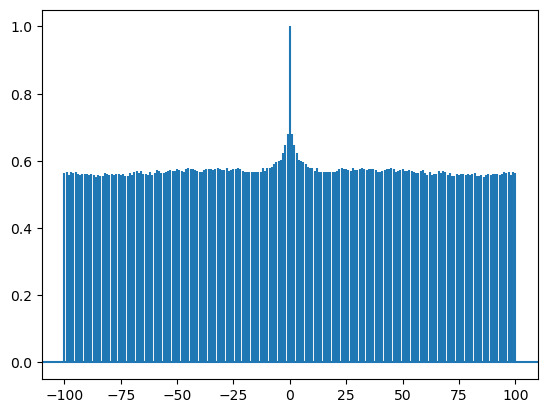

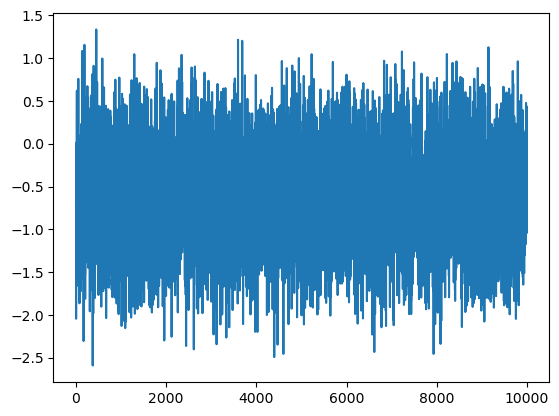

fates_hydro_kmax_rsurf2
0.000702


IndexError: single positional indexer is out-of-bounds

In [154]:
for i in list(range(0,10)):
    
        times=2
        print(V["b"][i])
        print(V["SD"][i]*times)
        plt.acorr(newlog.iloc[i,:].reset_index(drop=True).values[:].flatten(), maxlags = 100) 
        plt.show()
        plt.plot(newlog.iloc[i,:].reset_index(drop=True))
        plt.show()